<a href="https://colab.research.google.com/github/AlinaSabitova/Neural_networks/blob/main/%D0%91%D0%B8%D0%BB%D0%B5%D1%82_2_text_classification_%D1%80%D1%83%D1%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация текстов в TensorFlow

В этом блокноте решаются две задачи:
1. **Бинарная классификация** отзывов IMDB: положительный или отрицательный отзыв.
2. **Многоклассовая классификация** вопросов Stack Overflow: предсказать тег вопроса (`python`, `java`, `javascript`, `csharp`).

В данном билете рассматривается задача классификации текстов с использованием TensorFlow/Keras. Мы решаем две подзадачи: бинарную классификацию тональности отзывов (IMDB) и многоклассовую классификацию по темам/тегам (Stack Overflow). Это позволяет сравнить, как меняется последний слой сети и функция потерь в зависимости от количества классов.

## Подключение библиотек

In [18]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses

In [19]:
print(tf.__version__)

2.19.0


## Часть 1. IMDB — бинарная классификация

Сначала обучим модель, которая по тексту отзыва определяет настроение: **положительный** отзыв или **отрицательный**.

### 1. Скачивание и просмотр датасета
Первая задача — бинарная классификация отзывов IMDB. Мы скачиваем датасет с помощью встроенной утилиты get_file, которая автоматически сохраняет архив, распаковывает его и возвращает путь к файлам. Далее смотрим структуру папок: в директории train находятся папки pos (положительные отзывы) и neg (отрицательные отзывы). Папку unsup (неразмеченные данные) мы удаляем, так как для обучения с учителем она не нужна."

In [20]:
# Скачивание и предварительный осмотр датасета IMDB

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

# get_file скачивает файл по URL и распаковывает его (untar=True)
# cache_dir='.' и cache_subdir='' означают, что файлы сохранятся локально в текущей папке
dataset = tf.keras.utils.get_file("aclImdb_v1", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')

dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb_v1')

In [21]:
os.listdir(dataset_dir)

['aclImdb']

In [22]:
# Определяем пути к папкам train и test
train_dir = os.path.join(dataset_dir, 'aclImdb', 'train')
test_dir = os.path.join(dataset_dir, 'aclImdb', 'test')
os.listdir(train_dir)

['urls_unsup.txt',
 'unsupBow.feat',
 'urls_pos.txt',
 'pos',
 'urls_neg.txt',
 'neg',
 'labeledBow.feat',
 'unsup']

В папках `pos` и `neg` лежат текстовые файлы с отзывами. Посмотрим один пример.

In [23]:
sample_file = os.path.join(train_dir, 'pos', '1181_9.txt')
with open(sample_file) as f:
  print(f.read())

Rachel Griffiths writes and directs this award winning short film. A heartwarming story about coping with grief and cherishing the memory of those we've loved and lost. Although, only 15 minutes long, Griffiths manages to capture so much emotion and truth onto film in the short space of time. Bud Tingwell gives a touching performance as Will, a widower struggling to cope with his wife's death. Will is confronted by the harsh reality of loneliness and helplessness as he proceeds to take care of Ruth's pet cow, Tulip. The film displays the grief and responsibility one feels for those they have loved and lost. Good cinematography, great direction, and superbly acted. It will bring tears to all those who have lost a loved one, and survived.


### 2. Загрузка данных в TensorFlow

Создаём датасет из папок на диске. Для обучения нам нужны только классы `pos` и `neg`, поэтому папку `unsup` удаляем.

In [24]:
remove_dir = os.path.join(train_dir, 'unsup')
shutil.rmtree(remove_dir)

Разобьём данные на обучающую и валидационную части. Тестовую выборку берём отдельно из папки `test`.

Для эффективной загрузки данных мы используем text_dataset_from_directory. Эта функция сканирует папки и автоматически присваивает метки классам в алфавитном порядке. Здесь neg = 0, pos = 1. С помощью параметра validation_split=0.2 мы отщипываем 20% данных от обучающей выборки для валидации. Параметр seed=42 гарантирует, что при каждом запуске разбиение будет одинаковым. Также мы создаем чистый тестовый датасет из отдельной папки test.

In [25]:
batch_size = 32
seed = 42 # фиксируем генератор случайных чисел для воспроизводимости разбиения

# Создаем обучающую выборку (80% от train_dir)
raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


Проверим, как выглядят тексты и метки классов.

In [26]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
Label 0
Review b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they get into 

Метка `0` соответствует отрицательному отзыву, а `1` — положительному.

In [27]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])

Label 0 corresponds to neg
Label 1 corresponds to pos


Теперь создадим валидационную и тестовую выборки.

In [28]:
# Создаем валидационную выборку (оставшиеся 20% от train_dir)
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [29]:
# Создаем тестовую выборку (берется из отдельной папки test)
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    test_dir,
    batch_size=batch_size)

Found 25000 files belonging to 2 classes.


### 3. Предобработка текста

Нейросеть не умеет работать со строками напрямую, поэтому текст нужно подготовить:
- привести к нижнему регистру;
- убрать HTML-теги;
- убрать лишние символы;
- превратить слова в числа.

Для этого используем слой `TextVectorization`. Определяем функцию custom_standardization, которая приводит текст к нижнему регистру и удаляет HTML-теги и пунктуацию. Затем создается слой TextVectorization, который строит словарь из 10,000 самых частотных слов и приводит все тексты к фиксированной длине в 250 слов. Обратите внимание на метод adapt() — он вызывается только на обучающих данных, чтобы построить словарь. Это предотвращает утечку информации из валидационной и тестовой выборок

In [30]:
# Предобработка текста: стандартизация и векторизация
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

Задаём параметры векторизации: максимальный словарь, длину последовательности и сам слой.

In [31]:
max_features = 10000    # Размер словаря: запоминаем только 10,000 самых частых слов
sequence_length = 250   # Максимальная длина отзыва в словах (длинные обрежутся, короткие дополнятся нулями)

# Создаем слой векторизации
vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

Слой нужно "подстроить" под обучающие тексты. Для этого вызываем `adapt` только на train-данных.

In [32]:
# ВАЖНО: adapt() запускает сканирование текстов и построение словаря.
# Он должен вызываться ТОЛЬКО на train данных, чтобы не подглядывать в test/val.
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

Сделаем маленькую функцию, чтобы посмотреть, как текст превращается в последовательность чисел.

In [33]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [34]:
# retrieve a batch (of 32 reviews and labels) from the dataset
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'Silent Night, Deadly Night 5 is the very last of the series, and like part 4, it\'s unrelated to the first three except by title and the fact that it\'s a Christmas-themed horror flick.<br /><br />Except to the oblivious, there\'s some obvious things going on here...Mickey Rooney plays a toymaker named Joe Petto and his creepy son\'s name is Pino. Ring a bell, anyone? Now, a little boy named Derek heard a knock at the door one evening, and opened it to find a present on the doorstep for him. Even though it said "don\'t open till Christmas", he begins to open it anyway but is stopped by his dad, who scolds him and sends him to bed, and opens the gift himself. Inside is a little red ball that sprouts Santa arms and a head, and proceeds to kill dad. Oops, maybe he should have left well-enough alone. Of course Derek is then traumatized by the incident since he watched it from the stairs, but he doesn\'t grow up to be some killer Santa, he just stops talking.<br /><br />T

Можно даже посмотреть, какое слово скрывается за конкретным индексом словаря.

In [35]:
print("1287 ---> ",vectorize_layer.get_vocabulary()[1287])
print(" 313 ---> ",vectorize_layer.get_vocabulary()[313])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

1287 --->  silent
 313 --->  night
Vocabulary size: 10000


### 4. Векторизация train / val / test

Применим созданный слой ко всем выборкам.



In [36]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

### 5. Подготовка датасета для более быстрого обучения

`cache()` сохраняет данные в памяти после первого чтения, а `prefetch()` заранее готовит следующий батч.

In [37]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### 6. Построение модели

Модель состоит из нескольких слоёв:
- `Embedding` — превращает индексы слов в плотные числовые векторы;
- `Dropout` — помогает бороться с переобучением;
- `GlobalAveragePooling1D` — усредняет информацию по всей последовательности;
- `Dense(1)` — выдаёт итоговый логит для бинарной классификации.

Переходим к архитектуре нейронной сети. Модель состоит из нескольких слоев. Первый слой — Embedding. Он преобразует индексы слов в плотные векторы размерностью 16. Благодаря этому слова со схожим смыслом будут иметь близкие координаты в векторном пространстве. Далее идут слои Dropout для борьбы с переобучением и GlobalAveragePooling1D, который усредняет информацию по всей длине текста. Так как задача бинарная, последний слой имеет один нейрон с функцией активации sigmoid. В качестве функции потерь используем BinaryCrossentropy, оптимизатор — Adam.

In [38]:
embedding_dim = 16 # Размерность векторного представления одного слова

In [39]:
model = tf.keras.Sequential([
  # Слой эмбеддингов: на входе индексы слов (int), на выходе плотные векторы (float)
  layers.Embedding(max_features, embedding_dim),
  # Dropout выключает 20% случайных нейронов на каждом шаге обучения (регуляризация)
  layers.Dropout(0.2),
  # GlobalAveragePooling1D вычисляет среднее значение по каждому из 16 признаков для всей последовательности
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  # Выходной слой: 1 нейрон с сигмоидой -> число от 0 до 1 (вероятность положительного отзыва)
  layers.Dense(1, activation='sigmoid')
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Почему в model.summary() нули:

слои Embedding и Dense показываются как unbuilt;
значит модель ещё не “построена” (не инициализирована).

В TensorFlow модель “строится” только когда:

либо мы явно задаём input_shape,
либо модель впервые получает реальные данные (через fit, predict, build).

Сейчас:

объявлена архитектура,
но ещё не переданы данные → веса не созданы → параметров = 0.

### 7. Компиляция модели

Так как задача бинарная, используем функцию потерь `BinaryCrossentropy` и метрику `accuracy`.

In [41]:
model.compile(loss=losses.BinaryCrossentropy(),  # Стандартная функция потерь для бинарной классификации
              optimizer='adam',
              metrics=[tf.metrics.BinaryAccuracy(threshold=0.5)]) # Точность при пороге вероятности 0.5

### 8. Обучение модели

Обучим модель на train-выборке и будем следить за качеством на validation.

Запускаем обучение на 10 эпохах, передавая в метод fit обучающую и валидационную выборки. После обучения оцениваем качество на тестовой выборке с помощью evaluate. Обычно такая простая модель показывает точность около 85-87%, что является хорошим базовым результатом для начала. Далее мы строим графики изменения функции потерь и точности. На графиках видно, что и train, и validation кривые идут синхронно вниз (для loss) и вверх (для accuracy). Отсутствие расхождения говорит о том, что модель не переобучается.

In [42]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - binary_accuracy: 0.6469 - loss: 0.6604 - val_binary_accuracy: 0.7398 - val_loss: 0.6096
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7808 - loss: 0.5457 - val_binary_accuracy: 0.8052 - val_loss: 0.4981
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8322 - loss: 0.4459 - val_binary_accuracy: 0.8262 - val_loss: 0.4296
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8561 - loss: 0.3819 - val_binary_accuracy: 0.8444 - val_loss: 0.3840
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8710 - loss: 0.3403 - val_binary_accuracy: 0.8442 - val_loss: 0.3631
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.8816 - loss: 0.3103 - val_binary_accuracy: 0.8550 - val_loss: 0.3418
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8917 - loss: 0.2859 - val_binary_accuracy: 0.8576 - val_loss: 0.3290
Epoch 

### 9. Оценка качества на тестовой выборке

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8570 - loss: 0.3306
Loss:  0.33058905601501465
Accuracy:  0.8569999933242798


Обычно такая простая модель даёт точность примерно **85–87%**. Точное значение может немного меняться от запуска к запуску.

### 10. Графики обучения

Посмотрим, как менялись ошибка и точность на обучении и валидации.

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

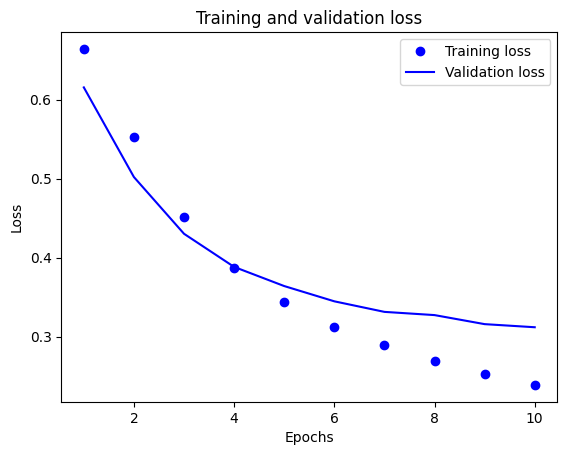

In [ ]:
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

График ошибки (loss)

Что видно:

и train, и validation loss уменьшаются;
сначала быстро, потом медленнее → модель обучается;
validation loss чуть выше train → это нормально.

Что это значит:

модель учится находить закономерности;
переобучения нет (валидация не растёт);
обучение стабильное.

Вывод: модель хорошо обучается и обобщает данные

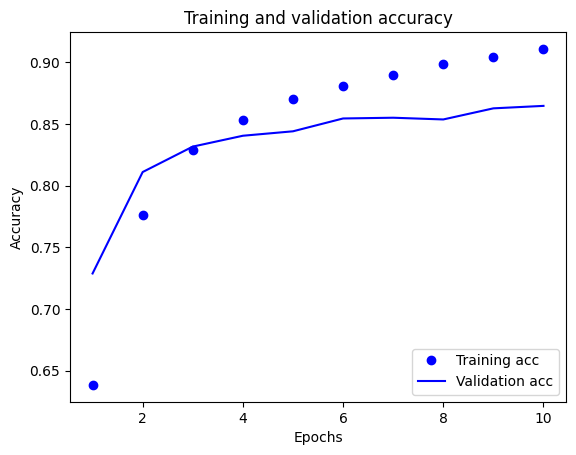

In [ ]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

График точности (accuracy)

Что видно:

точность на обучении растёт;
точность на валидации тоже растёт;
validation чуть ниже train.

Что это значит:

модель всё лучше классифицирует отзывы;
нет сильного разрыва между train и val → нет переобучения;
точность стабилизируется → модель достигла своего предела.

Вывод: модель показывает хорошее качество и не переобучается.

Если обучение идёт правильно, то train loss уменьшается, а train accuracy растёт. Если при этом валидационное качество перестаёт улучшаться, это признак начинающегося переобучения.

### 11. Экспорт модели

Ранее мы векторизовали текст **до** подачи в модель. Для удобства можно собрать экспортную модель, которая принимает уже **сырые строки**.

In [ ]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('sigmoid')
])

export_model.compile(
    loss=losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
metrics = export_model.evaluate(raw_test_ds, return_dict=True)
print(metrics)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5000 - loss: 0.5884
{'accuracy': 0.5, 'loss': 0.5884202718734741}


### 12. Предсказания на новых примерах

In [ ]:
examples = tf.constant([
  "The movie was great!",
  "The movie was okay.",
  "The movie was terrible..."
])

export_model.predict(examples)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


array([[0.58456767],
       [0.5493979 ],
       [0.5352744 ]], dtype=float32)

Такую экспортную модель удобно сохранять и использовать дальше, потому что вся предобработка уже встроена внутрь.

## Часть 2. Stack Overflow — многоклассовая классификация

Теперь решаем вторую задачу из билета: по тексту вопроса о программировании нужно определить его тег.

Классы такие:
- `python`
- `java`
- `javascript`
- `csharp`

Здесь уже **4 класса**, поэтому это не бинарная, а **многоклассовая** классификация.

Во второй части билета решается задача многоклассовой классификации на примере тегов Stack Overflow. Здесь 4 класса: python, java, javascript, csharp. Процесс загрузки и предобработки полностью аналогичен IMDB, но меняется архитектура выходного слоя. Теперь последний слой Dense имеет 4 нейрона — по одному на каждый класс. Мы не ставим активацию softmax явно, а передаем параметр from_logits=True в функцию потерь SparseCategoricalCrossentropy. Это численно более стабильный подход, так как Softmax вычисляется внутри функции потерь.

### 1. Скачивание датасета Stack Overflow

In [43]:
stack_url = "https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz"

stack_dataset = tf.keras.utils.get_file(
    "stack_overflow_16k",
    stack_url,
    untar=True,
    cache_dir='.',
    cache_subdir=''
)

stack_dataset_dir = os.path.join(os.path.dirname(stack_dataset), "stack_overflow_16k")
stack_dataset_dir

6053168/6053168 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


'./stack_overflow_16k'

Посмотрим на структуру папок. Каждая папка — это отдельный класс.

In [44]:
os.listdir(stack_dataset_dir)

['train', 'README.md', 'test']

In [45]:
train_stack_dir = os.path.join(stack_dataset_dir, "train")
test_stack_dir = os.path.join(stack_dataset_dir, "test")

os.listdir(train_stack_dir)

['java', 'python', 'javascript', 'csharp']

### 2. Загрузка train / validation / test

Как и в первой задаче, создаём датасеты напрямую из папок.

In [46]:
batch_size = 32
seed = 42

raw_train_stack_ds = tf.keras.utils.text_dataset_from_directory(
    train_stack_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

raw_val_stack_ds = tf.keras.utils.text_dataset_from_directory(
    train_stack_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

raw_test_stack_ds = tf.keras.utils.text_dataset_from_directory(
    test_stack_dir,
    batch_size=batch_size)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.
Found 8000 files belonging to 4 classes.
Using 1600 files for validation.
Found 8000 files belonging to 4 classes.


Проверим названия классов.

In [47]:
stack_class_names = raw_train_stack_ds.class_names
print("Классы:", stack_class_names)

Классы: ['csharp', 'java', 'javascript', 'python']


Посмотрим на один батч вопросов и меток.

In [48]:
for text_batch, label_batch in raw_train_stack_ds.take(1):
    for i in range(3):
        print("Текст вопроса:", text_batch.numpy()[i][:200])
        print("Метка:", label_batch.numpy()[i])
        print()

Текст вопроса: b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to '
Метка: 1

Текст вопроса: b'"blank code slow skin detection this code changes the color space to lab and using a threshold finds the skin area of an image. but it\'s ridiculously slow. i don\'t know how to make it faster ?    ..fr'
Метка: 3

Текст вопроса: b'"option and validation in blank i want to add a new option on my system where i want to add two text files, both rental.txt and customer.txt. inside each text are id numbers of the customer, the video'
Метка: 1



### 3. Предобработка текста

Используем ту же идею: чистим текст и переводим его в последовательности индексов.

In [49]:
max_features = 10000
sequence_length = 250

stack_vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [50]:
train_stack_text = raw_train_stack_ds.map(lambda x, y: x)
stack_vectorize_layer.adapt(train_stack_text)

Проверим, как работает векторизация на одном примере.

In [51]:
def vectorize_stack_text(text, label):
    text = tf.expand_dims(text, -1)
    return stack_vectorize_layer(text), label

text_batch, label_batch = next(iter(raw_train_stack_ds))
first_question, first_label = text_batch[0], label_batch[0]
print("Текст вопроса:")
print(first_question)
print()
print("Метка:", first_label)
print()
print("После векторизации:")
print(vectorize_stack_text(first_question, first_label)[0])

Текст вопроса:
tf.Tensor(b'"unit testing of setters and getters teacher wanted us to do a comprehensive unit test. for me, this will be the first time that i use junit. i am confused about testing set and get methods. do you think should i test them? if the answer is yes; is this code enough for testing?..  public void testsetandget(){.    int a = 10;.    class firstclass = new class();.    firstclass.setvalue(10);.    int value = firstclass.getvalue();.    assert.asserttrue(""error"", value==a);.  }...in my code, i think if there is an error, we can\'t know that the error is deriving because of setter or getter."\n', shape=(), dtype=string)

Метка: tf.Tensor(1, shape=(), dtype=int32)

После векторизации:
tf.Tensor(
[[1011  773    9 2456    8 1863 2362  690 1267    4   40    5    1 1011
   196   12   74   13   72   33    2   98  105   14    3   70 9611    3
    34  888  202  773  107    8   41  242   40   58  291   90    3  196
   191   10    2  182    6  668    6   13   30 1187   12  

Теперь применим слой ко всем выборкам и ускорим чтение данных.

In [52]:
train_stack_ds = raw_train_stack_ds.map(vectorize_stack_text)
val_stack_ds = raw_val_stack_ds.map(vectorize_stack_text)
test_stack_ds = raw_test_stack_ds.map(vectorize_stack_text)

AUTOTUNE = tf.data.AUTOTUNE

train_stack_ds = train_stack_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_stack_ds = val_stack_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_stack_ds = test_stack_ds.cache().prefetch(buffer_size=AUTOTUNE)

### 4. Построение модели для 4 классов

Архитектура похожа на IMDB, но последний слой теперь выдаёт **4 значения** — по одному на каждый класс.

In [53]:
embedding_dim = 16

stack_model = tf.keras.Sequential([
    layers.Embedding(max_features + 1, embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(len(stack_class_names))
])

Для многоклассовой задачи используем `SparseCategoricalCrossentropy`.

In [54]:
stack_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy'])

### 5. Обучение модели

In [55]:
stack_epochs = 10

stack_history = stack_model.fit(
    train_stack_ds,
    validation_data=val_stack_ds,
    epochs=stack_epochs)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3237 - loss: 1.3740 - val_accuracy: 0.3313 - val_loss: 1.3614
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4325 - loss: 1.3320 - val_accuracy: 0.4206 - val_loss: 1.3095
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5205 - loss: 1.2648 - val_accuracy: 0.5088 - val_loss: 1.2307
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5841 - loss: 1.1791 - val_accuracy: 0.6031 - val_loss: 1.1396
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6411 - loss: 1.0896 - val_accuracy: 0.7025 - val_loss: 1.0504
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6767 - loss: 1.0065 - val_accuracy: 0.7063 - val_loss: 0.9747
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7028 - loss: 0.9352 - val_accuracy: 0.7281 - val_loss: 0.9087
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7242 - loss: 0.8720 - val_accuracy: 0

### 6. Оценка качества на тестовой выборке

In [56]:
stack_loss, stack_accuracy = stack_model.evaluate(test_stack_ds)

print("Ошибка на тесте:", stack_loss)
print("Точность на тесте:", stack_accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7149 - loss: 0.8078
Ошибка на тесте: 0.8077766299247742
Точность на тесте: 0.7148749828338623


Точность здесь обычно получается заметно выше случайного угадывания. Случайное угадывание для 4 классов дало бы примерно 25%.

### 7. Графики обучения для Stack Overflow

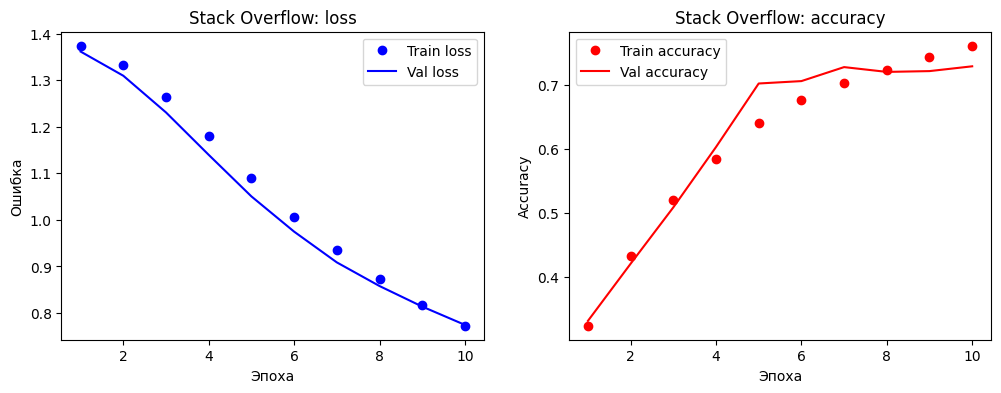

In [57]:
stack_history_dict = stack_history.history

stack_acc = stack_history_dict['accuracy']
stack_val_acc = stack_history_dict['val_accuracy']
stack_loss_values = stack_history_dict['loss']
stack_val_loss_values = stack_history_dict['val_loss']

epochs_range = range(1, len(stack_acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, stack_loss_values, 'bo', label='Train loss')
plt.plot(epochs_range, stack_val_loss_values, 'b', label='Val loss')
plt.title('Stack Overflow: loss')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, stack_acc, 'ro', label='Train accuracy')
plt.plot(epochs_range, stack_val_acc, 'r', label='Val accuracy')
plt.title('Stack Overflow: accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.show()



**1. График ошибки (loss)**

Что видно:

* ошибка на обучении уменьшается;
* ошибка на валидации тоже уменьшается;
* кривые идут почти параллельно.

Что это значит:

* модель успешно обучается;
* нет переобучения (валидация не растёт);
* обучение стабильное.

Вывод: модель постепенно лучше понимает данные и обобщает их.



**2. График точности (accuracy)**

Что видно:

* точность на обучении растёт;
* точность на валидации тоже растёт;
* значения близки (~0.7–0.75).

Что это значит:

* модель всё лучше определяет тег вопроса;
* нет сильного разрыва между train и val → нет переобучения;
* качество стабилизируется → модель “сошлась”.



**Что важно отметить:**

* задача сложнее, чем IMDB (там бинарная, здесь многоклассовая);
* поэтому точность ниже (~70–75%) — это нормально.


**Итог**
Ошибка уменьшается, точность растёт, при этом значения на обучении и валидации близки, что говорит об отсутствии переобучения. Модель обучается корректно и достигает стабильного качества около 70–75%, что нормально для многоклассовой задачи классификации текстов.


### 8. Экспорт модели и предсказания на новых примерах

In [58]:
stack_export_model = tf.keras.Sequential([
    stack_vectorize_layer,
    stack_model,
    layers.Activation('softmax')
])

stack_export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer='adam',
    metrics=['accuracy'])

In [59]:
examples = tf.constant([
    "How do I sort a dictionary by value in python?",
    "How can I create a class in java?",
    "How to change CSS style with javascript?",
    "How to read a file in csharp?"
])

predictions = stack_export_model.predict(examples)

for text, pred in zip(examples.numpy(), predictions):
    predicted_class = stack_class_names[int(tf.argmax(pred))]
    print("Вопрос:", text.decode("utf-8"))
    print("Предсказанный тег:", predicted_class)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Вопрос: How do I sort a dictionary by value in python?
Предсказанный тег: javascript

Вопрос: How can I create a class in java?
Предсказанный тег: javascript

Вопрос: How to change CSS style with javascript?
Предсказанный тег: javascript

Вопрос: How to read a file in csharp?
Предсказанный тег: javascript



## Короткий вывод

В этом блокноте были решены две задачи классификации текста:

1. **IMDB** — бинарная классификация отзывов на положительные и отрицательные.
2. **Stack Overflow** — многоклассовая классификация вопросов по тегам.

В обеих задачах использовалась одна и та же общая схема:
- загрузка текстов с диска;
- предобработка и векторизация;
- обучение нейросети;
- оценка качества на тестовой выборке;
- предсказания для новых текстов.

Главная разница между задачами — количество классов: в IMDB их 2, а в Stack Overflow — 4.